# 04 — Train Baseline Classifier

**Goal:** Train a pretrained ResNet50 on ISIC 2018 Task 3 to classify dermoscopic
images into 7 disease classes. This baseline gives us the reference numbers that
the generative-augmentation experiments (Phase 10) must beat.

**What this notebook does:**
1. Load `ISICDataset` (from `src/dataset.py`) with the standard ImageNet preprocessing
2. Build a ResNet50 with a new 7-class head (from `src/models/classifier.py`)
3. Train with class-weighted cross-entropy + early stopping
4. Track **macro-F1** (not raw accuracy — accuracy is misleading on imbalanced data)
5. Save the best checkpoint and per-epoch training logs
6. Evaluate on the held-out test set
7. Plot training curves and the confusion matrix

**Reproducibility:** all paths, seeds, and hyperparameters are set in cell 2 so this
notebook runs identically on any machine after pulling the repo.


In [1]:
# ============================================================
# Configuration — change values here, not in the rest of the notebook
# ============================================================

import sys
from pathlib import Path

# Project paths (notebook lives in notebooks/, so go up one level)
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

SPLITS_CSV   = PROJECT_ROOT / 'data/processed/splits.csv'
IMAGES_DIR   = PROJECT_ROOT / 'data/raw/ISIC2018_Task3_Training_Input'
RESULTS_DIR  = PROJECT_ROOT / 'results'
CHECKPT_DIR  = RESULTS_DIR / 'checkpoints'
PLOTS_DIR    = RESULTS_DIR / 'plots'
LOGS_DIR     = RESULTS_DIR / 'logs'

for d in (CHECKPT_DIR, PLOTS_DIR, LOGS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Hyperparameters
SEED          = 42
IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_WORKERS   = 0   # set 0 on Windows; 2-4 fine on Linux/Colab
NUM_EPOCHS    = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
ES_PATIENCE   = 5   # early stopping patience on val macro-F1
FREEZE_BACKBONE = True   # True = head-only training (fast, ~1M params)
                         # Set False later for full fine-tuning ablation

EXPERIMENT_NAME = 'baseline_resnet50'

print(f'Project root : {PROJECT_ROOT}')
print(f'Splits CSV   : {SPLITS_CSV.exists()}')
print(f'Images dir   : {IMAGES_DIR.exists()}')
print(f'Experiment   : {EXPERIMENT_NAME}')


Project root : /home/mayarn/skin-cancer/skin-lesion
Splits CSV   : True
Images dir   : True
Experiment   : baseline_resnet50


## Reproducibility

Fix every random source we know about: Python's `random`, NumPy, PyTorch (CPU + CUDA),
and cuDNN. This makes runs on the same machine deterministic — critical for the report,
because the professor cares about reproducibility (see course note 1).

In [2]:
import random
import numpy as np
import torch

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f'Seed fixed to {SEED}')


Seed fixed to 42


## Device check

Training on CPU is **not viable** for this project (a single epoch on 7,009 images
through ResNet50 takes hours). Confirm we have a CUDA GPU before running for real.
For local testing only, the notebook will still run on CPU with `NUM_EPOCHS=1`.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: no GPU detected. This will be extremely slow.')
    print('         Reduce NUM_EPOCHS to 1 for a CPU dry-run only.')


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA memory: 85.1 GB


## Data — transforms, datasets, loaders

**Train transforms:** resize → light augmentation (flips, rotation, color jitter) → ImageNet normalization.
**Val/test transforms:** resize → ImageNet normalization only (no augmentation — we evaluate on the real distribution).

ImageNet mean/std is required because we're using ResNet50 pretrained on ImageNet —
its first conv layer expects inputs in that distribution.

In [4]:
from torch.utils.data import DataLoader
from torchvision import transforms
from src.dataset import ISICDataset, CLASS_NAMES, LABEL_TO_IDX, get_class_weights

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='train', transform=train_transform)
val_ds   = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='val',   transform=eval_transform)
test_ds  = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='test',  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))

print(f'Train: {len(train_ds):5d} samples  →  {len(train_loader)} batches')
print(f'Val  : {len(val_ds):5d} samples  →  {len(val_loader)} batches')
print(f'Test : {len(test_ds):5d} samples  →  {len(test_loader)} batches')


Train:  7009 samples  →  220 batches
Val  :  1503 samples  →  47 batches
Test :  1503 samples  →  47 batches


## Model — ResNet50 with a new 7-class head

Pretrained on ImageNet (V2 weights — slightly better than V1). The backbone is
**frozen by default** so only the new final layer trains. This is the textbook
transfer-learning pattern from course note 9. Result: ~14k trainable params instead
of 25M, training is fast, and the rich ImageNet features still capture lesion patterns.

In [5]:
from src.models.classifier import build_resnet50_classifier, count_trainable_params, count_total_params

model = build_resnet50_classifier(num_classes=7, freeze_backbone=FREEZE_BACKBONE).to(device)

n_total  = count_total_params(model)
n_train  = count_trainable_params(model)
print(f'Total params     : {n_total:>11,}')
print(f'Trainable params : {n_train:>11,}  ({100*n_train/n_total:.2f}%)')
print(f'Backbone frozen  : {FREEZE_BACKBONE}')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/mayarn/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 222MB/s]


Total params     :  23,522,375
Trainable params :      14,343  (0.06%)
Backbone frozen  : True


## Loss, optimizer, scheduler

- **Loss:** `CrossEntropyLoss` weighted by inverse class frequency (rarer class → higher weight).
  This is the simplest baseline against which we'll compare generative augmentation.
- **Optimizer:** Adam — standard, robust default. Only the trainable parameters are passed
  (filters out frozen ones automatically).
- **Scheduler:** `ReduceLROnPlateau` watches val loss and halves the LR when it plateaus.

In [6]:
import torch.nn as nn
import torch.optim as optim

class_weights = get_class_weights(SPLITS_CSV, split='train').to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only optimize parameters that need gradients (works for frozen and unfrozen cases)
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print('Class weights:', class_weights.cpu().numpy().round(3))
print(f'Optimizer    : Adam(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})')
print(f'Scheduler    : ReduceLROnPlateau(factor=0.5, patience=2)')


Class weights: [ 1.285  0.213  2.781  4.372  1.302 12.516 10.114]
Optimizer    : Adam(lr=0.0001, weight_decay=0.0001)
Scheduler    : ReduceLROnPlateau(factor=0.5, patience=2)


## Early stopping

Identical pattern to `notes-6-code-2-earlystopping__1_.py` from your course materials —
stops training when validation loss hasn't improved for `patience` consecutive epochs.
Prevents overfitting and saves time when training has plateaued.

In [7]:
class EarlyStopping:
    """Stop training when validation loss stops improving.

    Same logic as the course's notes-6 early-stopping snippet.
    """
    def __init__(self, patience: int = 5, delta: float = 0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss: float):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
            print(f'   validation improved to {val_loss:.4f}')
        else:
            self.no_improvement_count += 1
        if self.no_improvement_count >= self.patience:
            self.stop_training = True

early_stopping = EarlyStopping(patience=ES_PATIENCE)


## Train / evaluate one epoch

Two helper functions:

- `train_one_epoch` — runs gradient updates, returns average loss + accuracy
- `evaluate` — no gradients, returns loss, accuracy, **macro-F1**, and all predictions
  (we'll use the predictions later for the confusion matrix)

**Why macro-F1?** With ~67% of the data being NV, a model that predicts "NV" for
everything gets ~67% accuracy but is useless. Macro-F1 averages F1 across all classes
equally, so the rare-class performance matters as much as the common class. This is
the metric we tune and report.

In [8]:
from sklearn.metrics import f1_score, accuracy_score

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    avg_loss = total_loss / len(all_labels)
    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, acc, macro_f1, all_preds, all_labels


## Training loop

For each epoch:
1. Train one pass over the training data
2. Evaluate on the validation set
3. Step the LR scheduler
4. Check early stopping
5. Save checkpoint if val macro-F1 improved
6. Log everything to a CSV

The CSV (`results/logs/baseline_resnet50.csv`) is what we'll plot from and put in the report.

In [9]:
import time
import pandas as pd

history = {
    'epoch': [], 'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_macro_f1': [], 'lr': [],
}

best_f1 = -1.0
best_ckpt_path = CHECKPT_DIR / f'{EXPERIMENT_NAME}_best.pt'
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_macro_f1'].append(val_f1)
    history['lr'].append(current_lr)

    elapsed = time.time() - epoch_start
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'train_loss={train_loss:.4f} acc={train_acc:.3f} | '
          f'val_loss={val_loss:.4f} acc={val_acc:.3f} f1={val_f1:.3f} | '
          f'lr={current_lr:.0e} | {elapsed:.1f}s')

    # Save best checkpoint by val macro-F1
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_macro_f1': val_f1,
            'val_loss': val_loss,
            'class_names': CLASS_NAMES,
        }, best_ckpt_path)
        print(f'   saved best checkpoint (val_f1={val_f1:.4f})')

    # Early stopping on val loss
    early_stopping.check_early_stop(val_loss)
    if early_stopping.stop_training:
        print(f'Early stopping at epoch {epoch}')
        break

total_time = time.time() - start_time
print(f'\nTotal training time: {total_time/60:.1f} min')
print(f'Best val macro-F1   : {best_f1:.4f}')
print(f'Best checkpoint     : {best_ckpt_path}')

# Save training log
log_df = pd.DataFrame(history)
log_path = LOGS_DIR / f'{EXPERIMENT_NAME}_log.csv'
log_df.to_csv(log_path, index=False)
print(f'Training log saved  : {log_path}')


Epoch 01/25 | train_loss=1.8683 acc=0.563 | val_loss=1.7895 acc=0.603 f1=0.301 | lr=1e-04 | 84.4s
   saved best checkpoint (val_f1=0.3012)
   validation improved to 1.7895
Epoch 02/25 | train_loss=1.7281 acc=0.633 | val_loss=1.6889 acc=0.609 f1=0.345 | lr=1e-04 | 84.5s
   saved best checkpoint (val_f1=0.3449)
   validation improved to 1.6889
Epoch 03/25 | train_loss=1.6324 acc=0.636 | val_loss=1.6296 acc=0.641 f1=0.360 | lr=1e-04 | 83.9s
   saved best checkpoint (val_f1=0.3601)
   validation improved to 1.6296
Epoch 04/25 | train_loss=1.5587 acc=0.624 | val_loss=1.5556 acc=0.637 f1=0.407 | lr=1e-04 | 85.7s
   saved best checkpoint (val_f1=0.4069)
   validation improved to 1.5556
Epoch 05/25 | train_loss=1.4983 acc=0.641 | val_loss=1.5528 acc=0.635 f1=0.435 | lr=1e-04 | 82.9s
   saved best checkpoint (val_f1=0.4353)
   validation improved to 1.5528
Epoch 06/25 | train_loss=1.4487 acc=0.633 | val_loss=1.4454 acc=0.613 f1=0.431 | lr=1e-04 | 83.3s
   validation improved to 1.4454
Epoch 07/

## Training curves

Two-panel plot: loss curves on the left, macro-F1 on the right. Three things to watch for:
- **Train loss falling, val loss rising** = overfitting (early stopping should catch this)
- **Both losses plateaued from epoch 1** = LR is too low or model is broken
- **Val macro-F1 should rise monotonically** in a healthy run

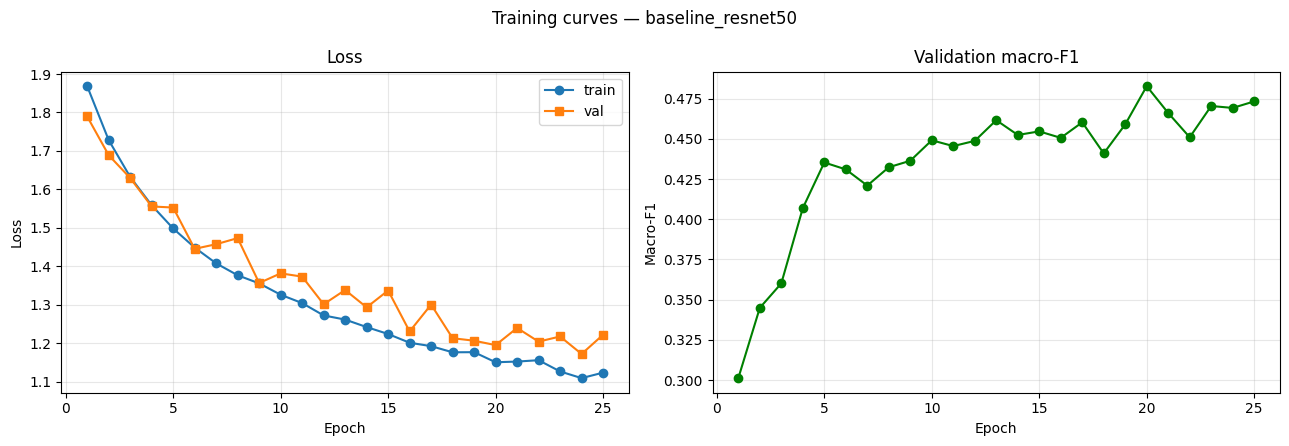

Saved: /home/mayarn/skin-cancer/skin-lesion/results/plots/baseline_resnet50_curves.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history['epoch'], history['train_loss'], label='train', marker='o')
axes[0].plot(history['epoch'], history['val_loss'],   label='val',   marker='s')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['epoch'], history['val_macro_f1'], color='green', marker='o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro-F1')
axes[1].set_title('Validation macro-F1'); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Training curves — {EXPERIMENT_NAME}')
plt.tight_layout()

curves_path = PLOTS_DIR / f'{EXPERIMENT_NAME}_curves.png'
plt.savefig(curves_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {curves_path}')


## Final evaluation on the test set

Load the best checkpoint (the one with the highest val macro-F1, not the last epoch).
The test set has never been seen during training or used for model selection, so these
numbers are the honest report numbers.

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

# Load best checkpoint
ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val_macro_f1={ckpt['val_macro_f1']:.4f})")

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f'\nTEST RESULTS — {EXPERIMENT_NAME}')
print('-' * 50)
print(f'Loss              : {test_loss:.4f}')
print(f'Accuracy          : {test_acc:.4f}')
print(f'Macro-F1          : {test_f1:.4f}')
print(f'Balanced accuracy : {balanced_accuracy_score(test_labels, test_preds):.4f}')

print('\nPer-class report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, zero_division=0))


Loaded checkpoint from epoch 20 (val_macro_f1=0.4827)

TEST RESULTS — baseline_resnet50
--------------------------------------------------
Loss              : 1.2764
Accuracy          : 0.6939
Macro-F1          : 0.4641
Balanced accuracy : 0.5498

Per-class report:
              precision    recall  f1-score   support

         MEL       0.36      0.47      0.40       167
          NV       0.91      0.80      0.85      1006
         BCC       0.52      0.52      0.52        77
       AKIEC       0.38      0.55      0.45        49
         BKL       0.52      0.43      0.47       165
          DF       0.15      0.35      0.21        17
        VASC       0.23      0.73      0.34        22

    accuracy                           0.69      1503
   macro avg       0.44      0.55      0.46      1503
weighted avg       0.75      0.69      0.71      1503



## Confusion matrix

Rows = true class, columns = predicted class. The diagonal is correct predictions.
**What to look for:** common confusions (e.g., MEL ↔ NV is the clinically important one)
and which rare classes the model just refuses to predict (a row of nearly-zeros for DF
means the model never says "DF" — that's the problem generative augmentation will try to fix).

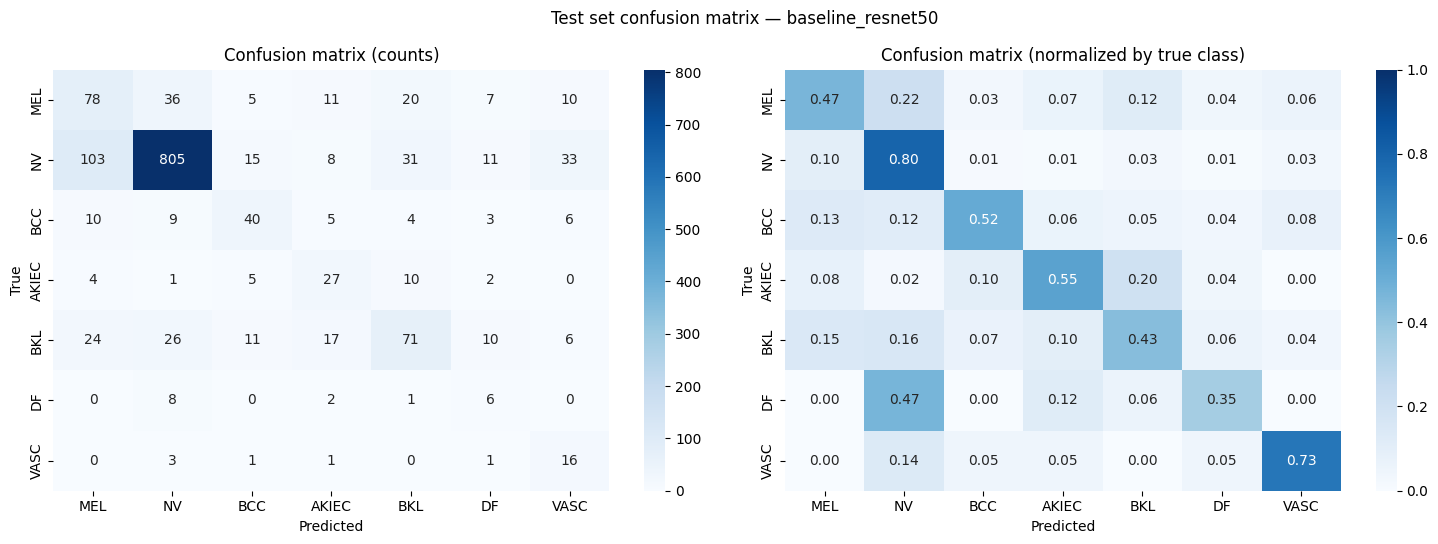

Saved: /home/mayarn/skin-cancer/skin-lesion/results/plots/baseline_resnet50_confusion.png
Saved: /home/mayarn/skin-cancer/skin-lesion/results/logs/baseline_resnet50_test_predictions.csv


In [12]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds, labels=list(range(7)))

# Normalize by row so each row sums to 1.0 — easier to read with imbalanced classes
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion matrix (counts)')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion matrix (normalized by true class)')

plt.suptitle(f'Test set confusion matrix — {EXPERIMENT_NAME}')
plt.tight_layout()

cm_path = PLOTS_DIR / f'{EXPERIMENT_NAME}_confusion.png'
plt.savefig(cm_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

# Save raw test predictions for later analysis (e.g. Grad-CAM, augmentation comparison)
results_df = pd.DataFrame({'true_label': test_labels, 'pred_label': test_preds})
results_path = LOGS_DIR / f'{EXPERIMENT_NAME}_test_predictions.csv'
results_df.to_csv(results_path, index=False)
print(f'Saved: {results_path}')


## Baseline trained

Artifacts saved (all under `results/`):
- `checkpoints/baseline_resnet50_best.pt` — best model weights
- `logs/baseline_resnet50_log.csv` — per-epoch training metrics
- `logs/baseline_resnet50_test_predictions.csv` — final test set predictions
- `plots/baseline_resnet50_curves.png` — training curves
- `plots/baseline_resnet50_confusion.png` — confusion matrix

**These numbers are the reference everything else must beat.**

Watch for these in your results:
- **Macro-F1** is the main number — likely 0.5–0.7 range for head-only training
- **NV recall** will be high (it's the majority class)
- **DF and VASC recall** will likely be low — *this is the gap generative augmentation is supposed to close*

